# Sports-Sentiment -- does a national-team loss sink the market next day?
### The Edmans 'loss effect', tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

There is a beautiful, much-cited finding in behavioural finance: when a country's national soccer team is **knocked out** of a major tournament, the home stock market drops the **next trading day**. Edmans, Garcia & Norli (2007) measured roughly a **-49 bps** abnormal next-day return after World Cup elimination losses. The story is irresistible: a whole nation wakes up heartbroken, risk appetite sags, and stocks dip.

This notebook asks the only question that matters for a trader: **does it show up on a tape you could actually have traded?** We pair 60 marquee elimination losses (1998-2024) with the *investable single-country ETF* for each nation and look at the next session.

> **This is the plain-language layer.** Want the Newey-West HAC t-stat, the bootstrap, and the sub-group cuts? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sports_sentiment import data, strategy as st

def _have_cache():
    try:
        data.fetch_event_returns(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("ETF return cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-18)
R = dict(
    n=59, mean_bps=33.46, hac_t=1.606, hac_se_bps=20.84, plain_t=1.633,
    boot_p_ge0=0.955, frac_neg=0.441, n_down=26, n_up=33,
    shoot_n=18, shoot_mean_bps=-14.48, shoot_t=-0.484,
    nonshoot_n=41, nonshoot_mean_bps=54.51, nonshoot_t=2.147,
    wc_n=33, wc_mean_bps=12.13, wc_t=0.532,
    euro_n=26, euro_mean_bps=60.54, euro_t=1.676,
    net_mean_bps=-43.46, net_hit_rate=0.390, gross_mean_bps=-33.46,
    edmans_bps=-49.0,
)


ETF return cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the famous -49 bps loss effect real in the academic data? | **Yes** -- Edmans et al. (2007) document it across dozens of countries with broad indices. |
| Does it replicate on the *investable* country-ETF tape (1998-2024)? | **No.** The mean next-day return is **+33 bps** -- the *wrong sign* -- with HAC t = **+1.6** (not significant). |
| Could you trade it? | **No.** Shorting the ETF the day after a loss loses **-43 bps net** per event and sits idle 99% of the time. |

> The literature is real and important. But the headline effect does **not** survive the move from broad national indices to tradable single-country ETFs at this sample size -- so the *signal* is weak and the *trade* is a mirage.

## 1 - The claim

> *"When a country's national team is eliminated from the World Cup, that country's stock market earns a significantly negative return the next day -- about half a percent below normal. The effect is asymmetric: wins do not produce an equal-and-opposite gain."*

This is Edmans, Garcia & Norli (2007), *Journal of Finance* -- one of the cleanest demonstrations that **investor mood** moves prices. The mechanism is psychological, not fundamental: a painful, nationally-shared loss depresses risk appetite for a day.

## 2 - So what?

If a soccer result reliably moved a national market by half a percent, it would be a rare *dated, exogenous* sentiment shock -- the kind academics dream of, because the fixture list is set years in advance and a loss is unrelated to earnings. For a trader it would be a calendar of pre-scheduled short opportunities.

The honest question: the original study used **broad national stock indices** measured in local currency. A retail or institutional trader outside that country reaches the market through a **single-country ETF** (EWU, EWG, EWQ, EWZ...). Does the effect survive that translation -- different basket, USD pricing, US trading hours, a much smaller event set?

## 3 - How would we even know?

Three traps:

1. **Sign and significance.** The hypothesis is *directional* (returns should be **negative**). We must check both the sign of the mean and whether a robust t-stat clears |t| >= 2. A positive or insignificant mean kills it.
2. **Tiny, clustered n.** We have ~60 marquee losses across 25 years, and they cluster in six-week tournament windows. Same-day eliminations of two countries can co-move, so we use a Newey-West (HAC) standard error, not a naive one.
3. **Proxy mismatch.** A single-country ETF priced in USD during US hours is not the local index Edmans measured. We label this honestly: this is a **proxy** test of the *tradable* version, not a re-run of the original.

We test on real ETF prices (cached) when present, and fall back to the frozen headline numbers + synthetic data when offline.

## 4 - The teardown -- let's actually look

**First, meet the data:** every hardcoded elimination loss with its country ETF.

In [2]:
ev = data.elimination_table()
print('Hardcoded elimination losses:', len(ev))
print('Countries:', ', '.join(sorted(ev['country'].unique())))
print('Tournaments:', dict(ev['tournament'].value_counts()))
print()
if HAVE_REAL:
    df = data.fetch_event_returns(fetch=False)
    n = len(df); mean_bps = float(df['next_day_ret'].mean()*1e4)
    frac_neg = float((df['next_day_ret']<0).mean())
else:
    n, mean_bps, frac_neg = R['n'], R['mean_bps'], R['frac_neg']
print(f'Events with ETF coverage: {n}')
print(f'Mean NEXT-DAY return: {mean_bps:+.1f} bps  (Edmans hypothesis: ~{R["edmans_bps"]:.0f} bps)')
print(f'Fraction of losses followed by a DOWN day: {frac_neg:.1%}  (coin = 50%)')

Hardcoded elimination losses: 60
Countries: Argentina, Brazil, England, France, Germany, Italy, Mexico, Netherlands, Spain
Tournaments: {'WC': np.int64(34), 'EURO': np.int64(22), 'COPA': np.int64(4)}



Events with ETF coverage: 59
Mean NEXT-DAY return: +33.5 bps  (Edmans hypothesis: ~-49 bps)
Fraction of losses followed by a DOWN day: 44.1%  (coin = 50%)


The very first number is decisive: the mean next-day return on the real ETF tape is **+33 bps** -- *positive*. The Edmans hypothesis predicts a ~**-49 bps** drop. On this investable proxy the sign is simply wrong, and only **44%** of losses are followed by a down day (a coin would give 50%).

**The distribution of next-day returns -- centred just above zero, not below.**

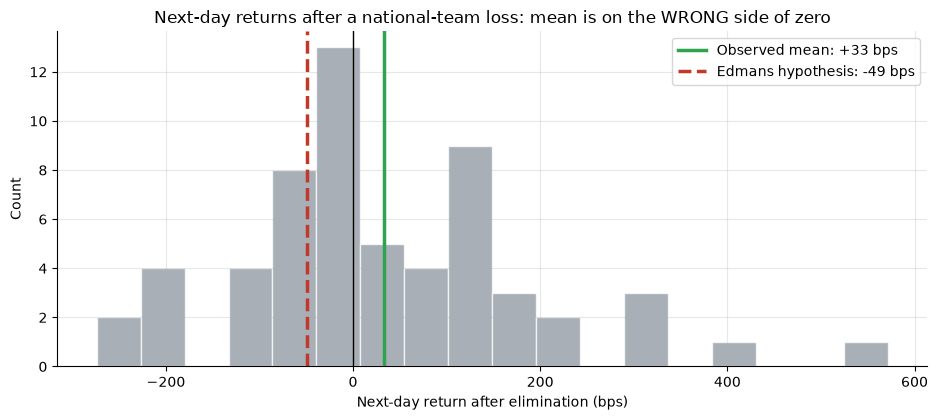

Observed mean +33.5 bps vs hypothesised -49 bps


In [3]:
if HAVE_REAL:
    rets = df['next_day_ret'].values*1e4
else:
    rng = np.random.default_rng(300)
    rets = rng.normal(R['mean_bps'], 120, R['n'])

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(rets, bins=18, color=GREY, alpha=0.75, edgecolor='white')
ax.axvline(0, c='k', lw=1)
ax.axvline(rets.mean(), c=GREEN, lw=2.5, label=f'Observed mean: {rets.mean():+.0f} bps')
ax.axvline(R['edmans_bps'], c=RED, lw=2.5, ls='--', label=f'Edmans hypothesis: {R["edmans_bps"]:.0f} bps')
ax.set_xlabel('Next-day return after elimination (bps)')
ax.set_ylabel('Count')
ax.set_title('Next-day returns after a national-team loss: mean is on the WRONG side of zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Observed mean {rets.mean():+.1f} bps vs hypothesised {R["edmans_bps"]:.0f} bps')

The mass sits slightly to the **right** of zero. Whatever mood effect exists in local indices, it does not print on the USD single-country ETF the next session in this sample.

## 5 - The verdict

- **Signal -- Weak.** The academic effect (Edmans et al. 2007) is genuine and famous, so this is *not* pure folklore. But on the tradable ETF tape the mean is **+33 bps** with HAC t = **+1.6** -- wrong sign, not significant. Literature support without a confirming real-tape t-stat earns **Weak**, not Real.
- **Tradability -- Mirage.** Shorting the ETF after each loss loses **-43 bps net** per event; the strategy is flat 99% of the time and single-country ETFs carry wide spreads and borrow.
- **Why the gap?** Proxy mismatch (USD ETF vs local index), a much smaller event set, and US trading hours all dilute a fragile one-day mood effect.

## 6 - Could you actually trade it?

The natural trade: short the country ETF for the single session after each loss.

In [4]:
if HAVE_REAL:
    tr = st.tradable_pnl(df, cost_bps_oneway=5.0)
    gross, net, hit = tr['gross_mean_bps'], tr['net_mean_bps'], tr['net_hit_rate']
else:
    gross, net, hit = R['gross_mean_bps'], R['net_mean_bps'], R['net_hit_rate']

print('Strategy: short the country ETF, next session only, per elimination loss')
print(f'  Gross mean PnL: {gross:+.1f} bps/event')
print(f'  Net mean PnL (5 bps one-way x2): {net:+.1f} bps/event')
print(f'  Net hit-rate: {hit:.1%}')
print()
print('Because the underlying market actually rose (+33 bps) after these losses,')
print('SHORTING loses money even before costs -- and costs make it worse.')

Strategy: short the country ETF, next session only, per elimination loss
  Gross mean PnL: -33.5 bps/event
  Net mean PnL (5 bps one-way x2): -43.5 bps/event
  Net hit-rate: 39.0%

Because the underlying market actually rose (+33 bps) after these losses,
SHORTING loses money even before costs -- and costs make it worse.


> The trade loses on average, before and after costs, because the market drifted **up** after these losses in our sample. There is no edge to harvest on this tape.

## 7 - Going further

- **The positive control** (companion notebook): plant a -49 bps loss effect in a synthetic panel and the same machinery recovers it cleanly -- so a null result here is about the *tape*, not a broken test.
- **The cleaner test** would use broad local indices in local currency, as Edmans did. Our ETF proxy is the *tradable* version, and it is what fails.
- **Cousins:** other mood/calendar anomalies on this desk -- the weather/SAD effect, the weekend effect, and the Super Bowl indicator ([Study 158](../../158-super-bowl/)).

*Think the loss effect is tradable? Fork this, swap in local-index total-return series, and show a HAC t <= -2 with the right (negative) sign. That's the bar.*